In [1]:
# 导入依赖
from collections import namedtuple
import numpy as np
import torch
import torch.nn as nn

# 超参数
HIDDEN_SIZE = 128      # 隐藏层神经元数量
BATCH_SIZE = 16        # 每批训练的回合数
PERCENTILE = 70        # 只取奖励在前 70% 的精英回合进行训练

In [2]:
class Net(nn.Module):
    """策略网络：输入观测值，输出每个动作的概率 logits"""
    def __init__(self, obs_size, hidden_size, n_actions):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),  # 输入层 → 隐藏层
            nn.ReLU(),                          # 激活函数
            nn.Linear(hidden_size, n_actions)   # 隐藏层 → 输出层（动作数）
        )

    def forward(self, x):
        return self.net(x)

In [3]:
# 使用 namedtuple 定义数据结构
Episode = namedtuple('Episode', field_names=['reward', 'steps'])
# Episode: 一个完整回合，包含总奖励和所有 step

EpisodeStep = namedtuple(
    'EpisodeStep', field_names=['observation', 'action'])
# EpisodeStep: 单个时间步，包含观测值和采取的动作

In [4]:
def iterate_batches(env, net, batch_size):
    """采样一批回合，筛选精英回合，返回 (obs, action) 训练数据"""
    batch = []                # 存放本批所有回合
    episode_reward = 0.0      # 当前回合累计奖励
    episode_steps = []        # 当前回合的所有 step
    obs = _reset(env)         # 兼容新旧 Gymnasium API
    sm = nn.Softmax(dim=1)    # 将 logits 转为概率分布

    while True:
        # 观测值转为 tensor，通过网络得到动作概率
        obs_v = torch.FloatTensor([obs])
        act_probs_v = sm(net(obs_v))
        act_probs = act_probs_v.data.numpy()[0]
        # 按概率分布随机采样动作
        action = np.random.choice(len(act_probs), p=act_probs)
        # 执行动作，获取下一步观测和奖励（兼容新旧 API）
        step_result = env.step(action)
        if len(step_result) == 4:
            next_obs, reward, done, _ = step_result
        else:
            next_obs, reward, done, truncated, _ = step_result
            done = done or truncated
        episode_reward += reward
        episode_steps.append(EpisodeStep(observation=obs, action=action))

        if done:
            # 回合结束，保存该回合
            batch.append(Episode(reward=episode_reward, steps=episode_steps))
            episode_reward = 0.0
            episode_steps = []
            next_obs = _reset(env)

            if len(batch) == batch_size:
                # 收集够一批，筛选精英回合并提取训练数据
                yield _filter_batch(batch, PERCENTILE)
                batch = []

        obs = next_obs


def _reset(env):
    """重置环境，兼容新旧 Gymnasium API（旧版返回 obs，新版返回 (obs, info)）"""
    result = env.reset()
    return result[0] if isinstance(result, tuple) else result


def _filter_batch(batch, percentile):
    """从一批回合中筛选奖励前 percentile% 的精英回合，提取训练数据"""
    # 计算精英阈值
    rewards = [episode.reward for episode in batch]
    reward_bound = np.percentile(rewards, percentile)

    train_obs, train_act = [], []
    for episode in batch:
        if episode.reward < reward_bound:
            continue  # 跳过非精英回合
        for step in episode.steps:
            train_obs.append(step.observation)
            train_act.append(step.action)

    return (
        torch.FloatTensor(train_obs),
        torch.LongTensor(train_act),
        reward_bound,            # 用于日志输出
        np.mean(rewards)         # 本批平均奖励
    )

In [5]:
# 训练主循环
import gymnasium as gym

# 创建环境，获取观测维度和动作数
env = gym.make("CartPole-v1")
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

# 初始化策略网络、损失函数和优化器
net = Net(obs_size, HIDDEN_SIZE, n_actions)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

# 记录训练历史，用于后续可视化
loss_history = []
mean_reward_history = []
reward_bound_history = []

# 训练循环：每批迭代一次
for batch_idx, (obs_t, act_t, reward_bound, mean_reward) in enumerate(iterate_batches(env, net, BATCH_SIZE)):
    # 前向传播 + 计算损失
    optimizer.zero_grad()
    logits = net(obs_t)
    loss = loss_fn(logits, act_t)
    loss.backward()
    optimizer.step()

    # 记录指标
    loss_history.append(loss.item())
    mean_reward_history.append(mean_reward)
    reward_bound_history.append(reward_bound)

    # 打印训练日志
    print(f"Batch {batch_idx:3d}: loss={loss.item():.4f}, "
          f"reward_bound={reward_bound:.1f}, mean_reward={mean_reward:.1f}")

    # CartPole 认为平均奖励 ≥ 195 即已解决
    if mean_reward >= 195:
        print(f"\nSolved in {batch_idx + 1} batches!")
        break

env.close()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/var/folders/fn/fb8vqk716bd4xpgc55y3fqdr0000gn/T/ipykernel_76049/3611486451.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  obs_v = torch.FloatTensor([obs])


Batch   0: loss=0.6937, reward_bound=23.5, mean_reward=22.6
Batch   1: loss=0.6907, reward_bound=26.5, mean_reward=22.1
Batch   2: loss=0.6802, reward_bound=27.5, mean_reward=27.8
Batch   3: loss=0.6683, reward_bound=32.0, mean_reward=26.1
Batch   4: loss=0.6531, reward_bound=46.5, mean_reward=42.6
Batch   5: loss=0.6508, reward_bound=32.0, mean_reward=34.1
Batch   6: loss=0.6297, reward_bound=61.0, mean_reward=50.6
Batch   7: loss=0.6186, reward_bound=35.0, mean_reward=32.2
Batch   8: loss=0.6038, reward_bound=49.5, mean_reward=43.1
Batch   9: loss=0.6145, reward_bound=57.0, mean_reward=45.6
Batch  10: loss=0.6257, reward_bound=61.0, mean_reward=56.7
Batch  11: loss=0.6197, reward_bound=71.0, mean_reward=59.1
Batch  12: loss=0.5863, reward_bound=79.0, mean_reward=64.1
Batch  13: loss=0.5933, reward_bound=99.0, mean_reward=76.6
Batch  14: loss=0.5880, reward_bound=118.5, mean_reward=91.8
Batch  15: loss=0.5752, reward_bound=142.0, mean_reward=120.5
Batch  16: loss=0.5734, reward_bound=

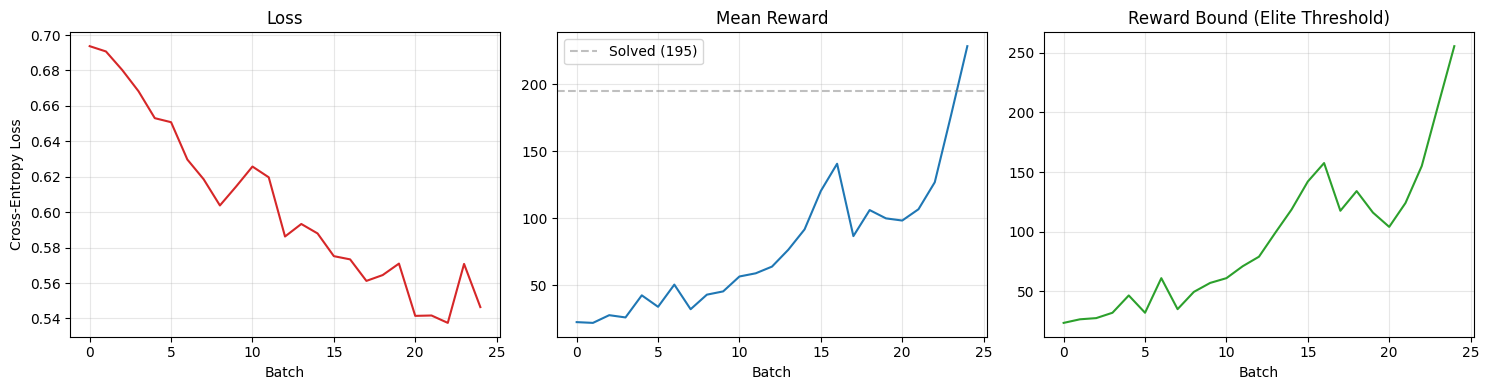

In [6]:
# 训练过程可视化
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history, color='tab:red')
axes[0].set_title('Loss')
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(mean_reward_history, color='tab:blue')
axes[1].set_title('Mean Reward')
axes[1].set_xlabel('Batch')
axes[1].axhline(y=195, color='gray', linestyle='--', alpha=0.5, label='Solved (195)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(reward_bound_history, color='tab:green')
axes[2].set_title('Reward Bound (Elite Threshold)')
axes[2].set_xlabel('Batch')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/RFlearning/lib/python3.9/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode reward: 500


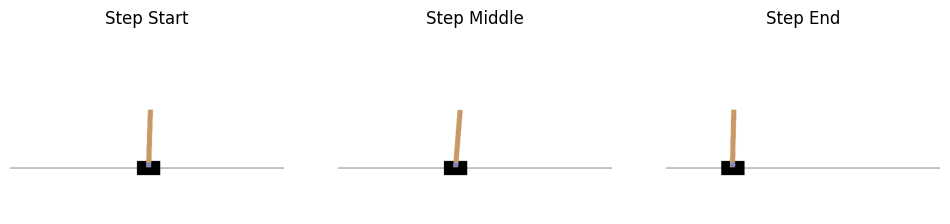

: 

In [ ]:
# 演示：用训练好的策略跑一个回合并显示关键帧
env_render = gym.make("CartPole-v1", render_mode="rgb_array")
obs = _reset(env_render)
sm = nn.Softmax(dim=1)

total_reward = 0.0
frames = []

while True:
    frames.append(env_render.render())  # 收集帧

    obs_v = torch.FloatTensor([obs])
    act_probs = sm(net(obs_v)).data.numpy()[0]
    action = np.argmax(act_probs)  # 演示时取最优动作

    step_result = env_render.step(action)
    if len(step_result) == 4:
        obs, reward, done, _ = step_result
    else:
        obs, reward, done, truncated, _ = step_result
        done = done or truncated
    total_reward += reward

    if done:
        break

env_render.close()

print(f"Episode reward: {total_reward:.0f}")

# 显示关键帧
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, idx in enumerate([0, len(frames) // 2, len(frames) - 1]):
    axes[i].imshow(frames[idx])
    axes[i].set_title(f"Step {['Start', 'Middle', 'End'][i]}")
    axes[i].axis('off')
plt.show()